# ParkSentinel AI — EDA & Coverage Priority Score (CPS)

**Theme 1: Parking-Induced Congestion — Bangalore Traffic Police**

This notebook documents the full exploratory analysis performed on the
provided dataset, including a timezone-conversion bug we caught and fixed
partway through (Section 3), and the computation of the Coverage Priority
Score used to rank junctions (Section 5).

All logic lives in `core_analysis.py` so the Streamlit dashboard and this
notebook never drift out of sync — this notebook calls those functions and
narrates what each one is doing and why.

In [1]:
import sys
sys.path.append("..")  # so core_analysis.py is importable when run from /notebooks

import pandas as pd
import matplotlib.pyplot as plt
import core_analysis as ca

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4)

DATA_PATH = "../data/jan_to_may_police_violation_anonymized791b166.csv.gz"

## 1. Load and inspect

In [2]:
raw = ca.load_raw(DATA_PATH)
print("Shape:", raw.shape)
raw.head(3)

Shape: (298450, 21)


,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,2023-11-28 04:48:04.582978+00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,2023-11-24 23:00:24.115257+00,FKDEV00001,FKUSR00001,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,2023-11-28 04:47:02.33776+00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00


In [3]:
print("Null counts:")
print(raw.isnull().sum())

Null counts:
id                                   0
latitude                             0
longitude                            0
location                          3041
vehicle_number                       0
vehicle_type                         0
violation_type                       0
offence_code                         0
created_datetime                     0
modified_datetime                    0
device_id                            0
created_by_id                        5
center_code                      11260
police_station                       5
data_sent_to_scita                   0
junction_name                        5
data_sent_to_scita_timestamp    256289
updated_vehicle_number          125254
updated_vehicle_type            125254
validation_status               125254
validation_timestamp            125254
dtype: int64


Three columns (`description`, `closed_datetime`, `action_taken_timestamp`)
are entirely null. Four others are null on the same ~125,000 rows,
consistent with those rows not having completed a review workflow yet.
`core_analysis.clean()` drops the dead columns and derives the fields we
need (parsed violation list, IST timestamps, etc).

In [4]:
df = ca.clean(raw)
df[["created_datetime", "created_ist", "hour", "violation_list", "primary_violation", "is_main_road"]].head()

,created_datetime,created_ist,hour,violation_list,primary_violation,is_main_road
0,2023-11-20 00:28:46+00:00,2023-11-20 05:58:46+00:00,5.0,"[WRONG PARKING, PARKING NEAR ROAD CROSSING]",WRONG PARKING,False
1,2023-11-24 22:46:46+00:00,2023-11-25 04:16:46+00:00,4.0,[NO PARKING],NO PARKING,False
2,2023-11-20 00:27:46+00:00,2023-11-20 05:57:46+00:00,5.0,"[WRONG PARKING, PARKING IN A MAIN ROAD]",WRONG PARKING,True
3,2023-11-16 06:47:46+00:00,2023-11-16 12:17:46+00:00,12.0,[NO PARKING],NO PARKING,False
4,2023-11-22 04:56:46+00:00,2023-11-22 10:26:46+00:00,10.0,[NO PARKING],NO PARKING,False


## 2. Dataset overview

In [5]:
import json
print(json.dumps(ca.headline_stats(df), indent=2))

{
  "total_records": 298450,
  "date_min": "2023-11-10",
  "date_max": "2024-04-08",
  "n_devices": 3070,
  "n_junctions": 169,
  "n_police_stations": 54,
  "n_vehicles": 231890,
  "n_violation_types": 17,
  "gap_share_pct": 1.44
}


## 3. Time-of-day analysis — and a timezone bug we caught

`created_datetime` is stored in **UTC**. Bengaluru is **UTC+5:30**. The
first time we ran this analysis, we read the hour directly off the raw UTC
timestamp without converting — here's what that looked like:

In [6]:
raw_hour_utc = pd.to_datetime(raw["created_datetime"], errors="coerce", utc=True).dt.hour
total = len(raw)
biz_wrong = ((raw_hour_utc >= 10) & (raw_hour_utc < 18)).sum()
night_wrong = ((raw_hour_utc >= 21) | (raw_hour_utc < 7)).sum()
print(f"[INCORRECT - raw UTC] 10am-6pm: {100*biz_wrong/total:.1f}%   9pm-7am: {100*night_wrong/total:.1f}%")

[INCORRECT - raw UTC] 10am-6pm: 0.9%   9pm-7am: 82.1%


This made it look like the system was blind during the day and only
active overnight — which would have pointed an entire enforcement
strategy at the wrong half of the day. After converting to IST:

In [7]:
bucketed = ca.bucketed_distribution(df)
bucketed

,bucket,count,share_pct
0,12am-3am,33174,11.12
1,3am-6am,67270,22.54
2,6am-9am,65071,21.80
3,9am-12pm,91750,30.74
4,12pm-3pm,36869,12.35
5,3pm-6pm,2184,0.73
6,6pm-9pm,219,0.07
7,9pm-12am,1908,0.64


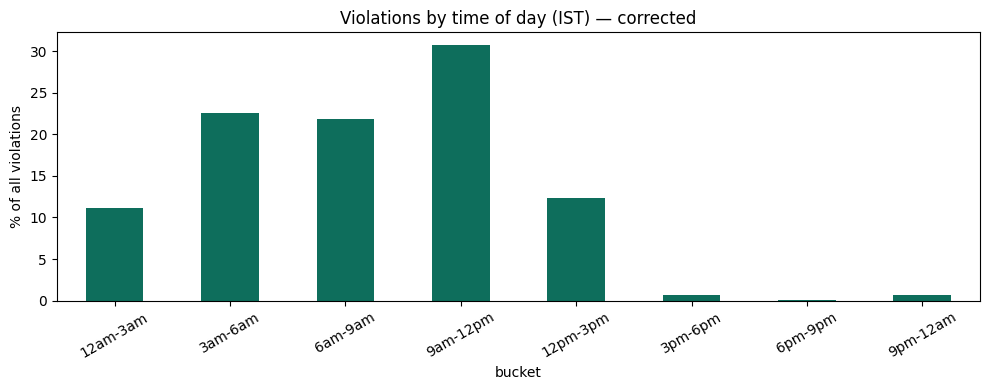

In [8]:
ax = bucketed.plot(x="bucket", y="share_pct", kind="bar", legend=False, color="#0E6E5C")
ax.set_ylabel("% of all violations")
ax.set_title("Violations by time of day (IST) — corrected")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Finding #1:** violations are dense from ~3am to 1pm IST and collapse to
near-zero from 3pm to midnight. Only **1.44%** of all 298,450 violations
are captured in that 3pm–midnight window — confirmed below, and also
confirmed to hold specifically within the "PARKING IN A MAIN ROAD" subset.

In [9]:
gap_pct = ca.coverage_gap_share(df) * 100
print(f"Share of violations in the 3pm-midnight IST gap: {gap_pct:.2f}%")

main_road = df[df["is_main_road"]]
gap_pct_main_road = ca.coverage_gap_share(main_road) * 100
print(f"Same gap, restricted to main-road violations only: {gap_pct_main_road:.2f}%")

Share of violations in the 3pm-midnight IST gap: 1.44%
Same gap, restricted to main-road violations only: 2.35%


## 4. Data-quality check — rejection rate by violation type

The `validation_status` field records manual-review outcomes for
camera-flagged incidents. This is a useful, already-measured baseline
accuracy figure for the *existing* system, before any new AI is added.

In [10]:
status_breakdown = ca.validation_status_breakdown(df)
status_breakdown

,status,count,share_pct
0,approved,115400,66.6
1,rejected,49754,28.7
2,created1,7044,4.1
3,processing,678,0.4
4,duplicate,320,0.2


In [11]:
rejection = ca.rejection_rate_by_type(df, min_n=200)
rejection

,violation_type,n_reviewed,n_rejected,rejection_rate_pct
0,PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC,403,145,36.0
1,DEFECTIVE NUMBER PLATE,515,171,33.2
2,WRONG PARKING,85253,27360,32.1
3,PARKING NEAR ROAD CROSSING,445,141,31.7
4,PARKING ON FOOTPATH,1348,418,31.0
5,PARKING IN A MAIN ROAD,8957,2681,29.9
6,NO PARKING,75826,18651,24.6


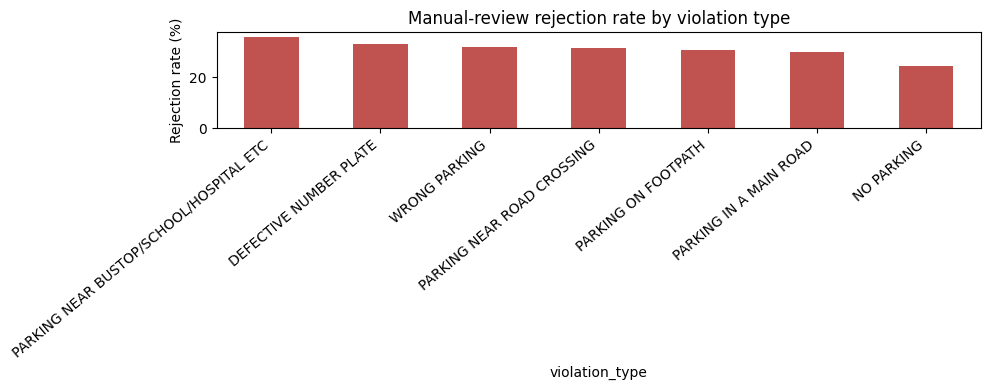

In [12]:
ax = rejection.plot(x="violation_type", y="rejection_rate_pct", kind="bar", legend=False, color="#C0524F")
ax.set_ylabel("Rejection rate (%)")
ax.set_title("Manual-review rejection rate by violation type")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

**Finding #2:** rejection rate is consistently 24–36% across every major
violation category — not concentrated in one type. This is the accuracy
ceiling of the *current* pipeline; any proposed CV system should be
designed to beat it (see the dwell-time-confirmation stage in
`cv_pipeline/`), not just match it.

## 5. Repeat offenders

In [13]:
import json
print(json.dumps(ca.repeat_offender_summary(df), indent=2))

{
  "n_vehicles_total": 231890,
  "n_repeat_10plus": 711,
  "rows_from_repeat_10plus": 9975,
  "rows_from_repeat_10plus_pct": 3.34,
  "n_repeat_2plus": 35587,
  "rows_from_repeat_2plus_pct": 34.23
}


## 6. Junction recovery — recovering the ~49.5% of rows with no junction tag

Roughly half of all rows have `junction_name == "No Junction"`, despite
every one of them having usable latitude/longitude. Most analyses would
silently drop these. We recover them by matching each unmapped row to its
nearest *named* junction centroid (deterministic haversine distance, not a
trained model), within a 500m cap so we never force a false match.

In [14]:
recovered = ca.recover_unmapped_junctions(df, max_distance_km=0.5)
import json
print(json.dumps(ca.recovery_summary(recovered), indent=2))

{
  "total_rows": 298450,
  "n_originally_unmapped": 147880,
  "pct_originally_unmapped": 49.55,
  "n_recovered": 16586,
  "pct_of_unmapped_recovered": 11.22,
  "median_recovery_distance_km": 0.3129
}


Only ~11% of unmapped rows are within 500m of a known junction — most are
genuinely far from any of the 169 curated junctions. That's itself a
finding about how incomplete the junction list is, not a failure of the
matching method. CPS below is computed on this recovered junction set, so
it matches the dashboard's default behavior.

## 7. Coverage Priority Score (CPS)

CPS ranks junctions by a blend of four factors instead of raw violation
count. See the project README for the plain-language explanation of why
raw counts are misleading and what each weight represents. In short:

```
CPS = 0.40 × coverage_gap + 0.30 × main_road_share
    + 0.20 × repeat_offender_share + 0.10 × violation_density
```

Junctions with fewer than 200 total violations are excluded before scoring,
because percentage-based components get noisy at low sample sizes.

In [15]:
cps = ca.compute_cps(recovered, min_volume=200, junction_col="junction_name_recovered")
cps[["rank", "junction_name", "n", "CPS", "coverage_gap_pct", "main_road_share_pct", "repeat_share_pct"]].head(15)

,rank,junction_name,n,CPS,coverage_gap_pct,main_road_share_pct,repeat_share_pct
0,1,BTP051 - Safina Plaza Junction,18923,12.55,1.0,1.7,8.2
1,2,BTP140 - Madiwala Check Post,372,11.97,8.3,28.5,0.0
2,3,BTP126 - Dairy Circle,334,11.12,0.0,36.8,0.0
3,4,BTP082 - KR Market Junction,11539,11.02,9.7,2.5,1.6
4,5,BTP098 - Nayandahalli Junction,220,10.51,0.0,35.0,0.0
5,6,"BTP170 - Dr. Bheem Rao Palace, Chord Road",573,9.13,1.7,15.7,17.6
6,7,"BTP083 - AS Char Street, Mysore Road",2786,9.09,5.3,18.2,0.7
7,8,BTP135 - UCO Bank Junction,1269,8.72,14.6,7.6,0.2
8,9,BTP091 - Sirsi Circle,263,8.47,0.0,28.1,0.0
9,10,BTP096 - Gali Anjaneya Temple,974,8.25,4.5,20.0,0.1


Note junction rank #5, **Nayandahalli Junction** — only 206 total
violations, which would not place in any top-20 ranking by raw count, but
its 35.9% main-road share surfaces it as a genuine priority. This is the
core value of CPS: it disagrees with a simple leaderboard on purpose.

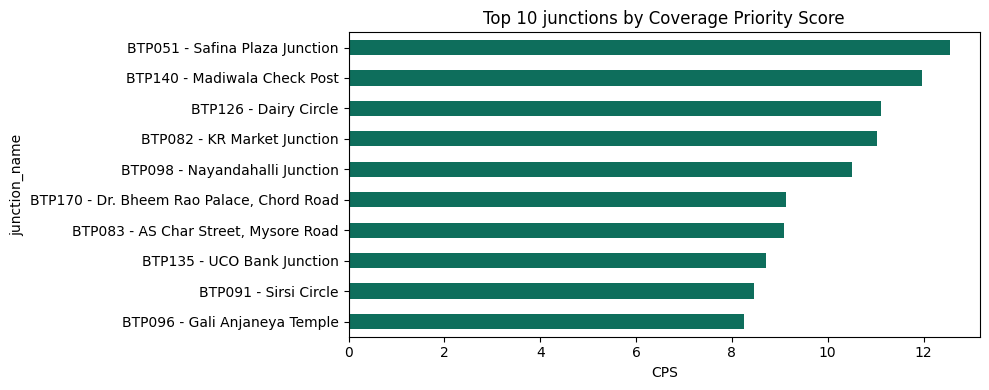

In [16]:
ax = cps.head(10).plot(x="junction_name", y="CPS", kind="barh", legend=False, color="#0E6E5C")
ax.invert_yaxis()
ax.set_xlabel("CPS")
ax.set_title("Top 10 junctions by Coverage Priority Score")
plt.tight_layout()
plt.show()

## 8. Clustering cross-check — an independent method, not just a formula

CPS uses fixed, hand-chosen weights. To check whether its priorities are
actually supported by the data (rather than an artifact of our weight
choices), we run **k-means clustering** on the same four underlying
features, with no weights imposed. This is genuine unsupervised ML — it
needs no labels, which this dataset doesn't have for a supervised model
anyway.

In [17]:
clustered = ca.cluster_junctions(cps, n_clusters=3)
clustered["tier"].value_counts()

tier
Low priority       72
High priority      16
Medium priority    12
Name: count, dtype: int64

In [18]:
centers = ca.cluster_centers_summary(cps, n_clusters=3)
centers[["tier", "n_junctions", "coverage_gap_pct", "main_road_share_pct", "repeat_share_pct", "density_norm_pct"]]

,tier,n_junctions,coverage_gap_pct,main_road_share_pct,repeat_share_pct,density_norm_pct
1,High priority,16,2.5,20.8,0.4,2.9
0,Low priority,72,0.7,2.7,1.1,4.7
2,Medium priority,12,1.2,2.7,10.9,30.6


The "High priority" tier is defined mainly by **main-road share** (~21% on
average, vs ~3% in other tiers) — i.e. clustering independently discovered
that main-road blockage is the dominant distinguishing feature, without
being told CPS weights it second-highest at 0.30.

In [19]:
agreement = ca.cps_vs_cluster_agreement(clustered, top_n=10)
print(f"Agreement with CPS top 10: {agreement['pct_agreement']}% ({agreement['n_overlap']}/10)")
print()
print("Junctions CPS ranks highly that clustering does NOT place in 'High priority':")
import pandas as pd
pd.DataFrame(agreement["disagreement_junctions"])

Agreement with CPS top 10: 70.0% (7/10)

Junctions CPS ranks highly that clustering does NOT place in 'High priority':


,junction_name,CPS,tier,coverage_gap_pct,main_road_share_pct,repeat_share_pct,density_norm_pct
0,"BTP170 - Dr. Bheem Rao Palace, Chord Road",9.13,Medium priority,1.7,15.7,17.6,2.0
1,BTP082 - KR Market Junction,11.02,Medium priority,9.7,2.5,1.6,60.6
2,BTP051 - Safina Plaza Junction,12.55,Medium priority,1.0,1.7,8.2,100.0


**70% agreement is a meaningful, honest result** — not perfect (which would
be suspicious, since the methods would then not really be independent), and
not low either. The 3 disagreements are explainable: those junctions score
high on CPS mostly via raw violation density (CPS weight 0.10), while
clustering's high-priority tier is defined by main-road share. This is a
real methodological difference between the two approaches, not noise.

## 9. Export scored junctions for the dashboard

In [20]:
cps.to_csv("../data/junctions_scored.csv", index=False)
bucketed.to_csv("../data/hourly_distribution.csv", index=False)
rejection.to_csv("../data/rejection_by_type.csv", index=False)
print("Exported junctions_scored.csv, hourly_distribution.csv, rejection_by_type.csv to ../data/")

Exported junctions_scored.csv, hourly_distribution.csv, rejection_by_type.csv to ../data/


## 10. Limitations (carried over from the technical proposal)

- The 3pm–midnight gap is a robust pattern in this data, but this dataset
  alone cannot confirm *why* (camera/staffing schedule vs. genuine
  behavioral difference). Recommended next step: audit camera uptime logs.
- The CPS weights are a reasoned prioritization, not values fitted to a
  real congestion outcome — this dataset has no traffic-speed or delay
  field to fit against. Phase 3 of the rollout plan (live traffic-speed
  API) is designed specifically to make that validation possible.
- ~49.5% of rows have no junction tag and are excluded from CPS scoring
  entirely; a complete system would recover them via lat/long geofencing.